<a href="https://colab.research.google.com/github/venezianof/booksum/blob/main/gemini_promptb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import google.generativeai as genai
import json
import random
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass
import numpy as np
from collections import Counter

def setup_gemini(api_key: str = None):
    if api_key is None:
        # In a real Colab environment, you might use secrets or a direct input
        # For demonstration, we'll use a placeholder or assume it's set up externally.
        print("Gemini API key is required. Please set it up or provide it.")
        # You would typically prompt for input here: api_key = input("Enter your Gemini API key: ").strip()
        # Or use a placeholder for testing without API key
        api_key = "YOUR_API_KEY"
    genai.configure(api_key=api_key)
    model = genai.GenerativeModel('gemini-2.0-flash-exp')
    print("✓ Gemini 2.0 Flash configured")
    return model

@dataclass
class Example:
    text: str
    sentiment: str
    def to_dict(self):
        return {"text": self.text, "sentiment": self.sentiment}

@dataclass
class Prediction:
    sentiment: str
    reasoning: str = ""
    confidence: float = 1.0

def create_dataset() -> Tuple[List[Example], List[Example]]:
    train_data = [
        Example("This movie was absolutely fantastic! Best film of the year.", "positive"),
        Example("Terrible experience, waste of time and money.", "negative"),
        Example("The product works as expected, nothing special.", "neutral"),
        Example("I'm blown away by the quality and attention to detail!", "positive"),
        Example("Disappointing and overpriced. Would not recommend.", "negative"),
        Example("It's okay, does the job but could be better.", "neutral"),
        Example("Incredible customer service and amazing results!", "positive"),
        Example("Complete garbage, broke after one use.", "negative"),
        Example("Average product, met my basic expectations.", "neutral"),
        Example("Revolutionary! This changed everything for me.", "positive"),
        Example("Frustrating bugs and poor design choices.", "negative"),
        Example("Decent quality for the price point.", "neutral"),
        Example("Exceeded all my expectations, truly remarkable!", "positive"),
        Example("Worst purchase I've ever made, avoid at all costs.", "negative"),
        Example("It's fine, nothing to complain about really.", "neutral"),
        Example("Absolutely stellar performance, 5 stars!", "positive"),
        Example("Broken and unusable, total disaster.", "negative"),
        Example("Meets requirements, standard quality.", "neutral"),
    ]
    val_data = [
        Example("Absolutely love it, couldn't be happier!", "positive"),
        Example("Broken on arrival, very upset.", "negative"),
        Example("Works fine, no major issues.", "neutral"),
        Example("Outstanding performance and great value!", "positive"),
        Example("Regret buying this, total letdown.", "negative"),
        Example("Adequate for basic use.", "neutral"),
    ]
    return train_data, val_data

class PromptTemplate:
    def __init__(self, instruction: str = "", examples: List[Example] = None):
        self.instruction = instruction
        self.examples = examples or []
    def format(self, text: str) -> str:
        prompt_parts = []
        if self.instruction:
            prompt_parts.append(self.instruction)
        if self.examples:
            prompt_parts.append("\nExamples:")
            for ex in self.examples:
                prompt_parts.append(f"\nText: {ex.text}")
                prompt_parts.append(f"Sentiment: {ex.sentiment}")
        prompt_parts.append(f"\nText: {text}")
        prompt_parts.append("Sentiment:")
        return "\n".join(prompt_parts)
    def clone(self):
        return PromptTemplate(self.instruction, self.examples.copy())

class SentimentModel:
    def __init__(self, model, prompt_template: PromptTemplate):
        self.model = model
        self.prompt_template = prompt_template

    def predict(self, text: str) -> Prediction:
        prompt = self.prompt_template.format(text)
        try:
            response = self.model.generate_content(prompt)
            result = response.text.strip().lower()
            for sentiment in ['positive', 'negative', 'neutral']:
                if sentiment in result:
                    return Prediction(sentiment=sentiment, reasoning=result)
            return Prediction(sentiment='neutral', reasoning=result)
        except Exception as e:
            return Prediction(sentiment='neutral', reasoning=str(e))

    def evaluate(self, dataset: List[Example]) -> float:
        correct = 0
        for example in dataset:
            pred = self.predict(example.text)
            if pred.sentiment == example.sentiment:
                correct += 1
        return (correct / len(dataset)) * 100

class PromptOptimizer:
    def __init__(self, model):
        self.model = model
        self.instruction_candidates = [
            "Analyze the sentiment of the following text. Classify as positive, negative, or neutral.",
            "Classify the sentiment: positive, negative, or neutral.",
            "Determine if this text expresses positive, negative, or neutral sentiment.",
            "What is the emotional tone? Answer: positive, negative, or neutral.",
            "Sentiment classification (positive/negative/neutral):",
            "Evaluate sentiment and respond with exactly one word: positive, negative, or neutral.",
        ]

    def select_best_examples(self, train_data: List[Example], val_data: List[Example], n_examples: int = 3) -> List[Example]:
        best_examples = None
        best_score = 0
        for _ in range(10):
            examples_by_sentiment = {
                'positive': [e for e in train_data if e.sentiment == 'positive'],
                'negative': [e for e in train_data if e.sentiment == 'negative'],
                'neutral': [e for e in train_data if e.sentiment == 'neutral']
            }
            selected = []
            for sentiment in ['positive', 'negative', 'neutral']:
                if examples_by_sentiment[sentiment]:
                    selected.append(random.choice(examples_by_sentiment[sentiment]))
            remaining = [e for e in train_data if e not in selected]
            while len(selected) < n_examples and remaining:
                selected.append(random.choice(remaining))
                remaining.remove(selected[-1])
            template = PromptTemplate(instruction=self.instruction_candidates[0], examples=selected)
            test_model = SentimentModel(self.model, template)
            score = test_model.evaluate(val_data[:3])
            if score > best_score:
                best_score = score
                best_examples = selected
        return best_examples

    def optimize_instruction(self, examples: List[Example], val_data: List[Example]) -> str:
        best_instruction = self.instruction_candidates[0]
        best_score = 0
        for instruction in self.instruction_candidates:
            template = PromptTemplate(instruction=instruction, examples=examples)
            test_model = SentimentModel(self.model, template)
            score = test_model.evaluate(val_data)
            if score > best_score:
                best_score = score
                best_instruction = instruction
        return best_instruction

    def compile(self, train_data: List[Example], val_data: List[Example], n_examples: int = 3) -> PromptTemplate:
        best_examples = self.select_best_examples(train_data, val_data, n_examples)
        best_instruction = self.optimize_instruction(best_examples, val_data)
        optimized_template = PromptTemplate(instruction=best_instruction, examples=best_examples)
        return optimized_template

def main():
    print("="*70)
    print("Prompt Optimization Tutorial")
    print("Stop Writing Prompts, Start Programming Them!")
    print("="*70)

    model = setup_gemini()
    train_data, val_data = create_dataset()
    print(f"✓ {len(train_data)} training examples, {len(val_data)} validation examples")

    baseline_template = PromptTemplate(
        instruction="Classify sentiment as positive, negative, or neutral.",
        examples=[]
    )
    baseline_model = SentimentModel(model, baseline_template)
    baseline_score = baseline_model.evaluate(val_data)

    manual_examples = train_data[:3]
    manual_template = PromptTemplate(
        instruction="Classify sentiment as positive, negative, or neutral.",
        examples=manual_examples
    )
    manual_model = SentimentModel(model, manual_template)
    manual_score = manual_model.evaluate(val_data)

    optimizer = PromptOptimizer(model)
    optimized_template = optimizer.compile(train_data, val_data, n_examples=4)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [7]:
if __name__ == "__main__":
    main()

Prompt Optimization Tutorial
Stop Writing Prompts, Start Programming Them!
Gemini API key is required. Please set it up or provide it.


AttributeError: module 'google.genai' has no attribute 'set_api_key'

In [6]:
import google.genai as genai
import json
import random
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass
import numpy as np
from collections import Counter

def setup_gemini(api_key: str = None):
    if api_key is None:
        # In a real Colab environment, you might use secrets or a direct input
        # For demonstration, we'll use a placeholder or assume it's set up externally.
        print("Gemini API key is required. Please set it up or provide it.")
        # You would typically prompt for input here: api_key = input("Enter your Gemini API key: ").strip()
        # Or use a placeholder for testing without API key
        api_key = "YOUR_API_KEY"
    genai.set_api_key(api_key)
    model = genai.GenerativeModel('gemini-2.0-flash-exp')
    print("✓ Gemini 2.0 Flash configured")
    return model

@dataclass
class Example:
    text: str
    sentiment: str
    def to_dict(self):
        return {"text": self.text, "sentiment": self.sentiment}

@dataclass
class Prediction:
    sentiment: str
    reasoning: str = ""
    confidence: float = 1.0

In [8]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 50.7 MB/s eta 0:00:00


# Deep Medical Research Agent
This agent is designed to perform deep searches on PubMed/Medline and format clinical bibliographies.

In [11]:
from Bio import Entrez
import pandas as pd
from datetime import datetime

class MedicalResearchAgent:
    def __init__(self, email: str):
        """Initialize with email (required by NCBI PubMed API)."""
        Entrez.email = email
        self.history = []

    def search_pubmed(self, query: str, max_results: int = 10):
        """Search PubMed and return a list of IDs."""
        try:
            handle = Entrez.esearch(db="pubmed", term=query, retmax=max_results)
            record = Entrez.read(handle)
            handle.close()
            return record.get("IdList", [])
        except Exception as e:
            print(f"Error searching PubMed: {e}")
            return []

    def fetch_details(self, id_list: list):
        """Fetch bibliographic details for a list of PubMed IDs."""
        if not id_list:
            return []

        ids = ",".join(id_list)
        try:
            handle = Entrez.efetch(db="pubmed", id=ids, rettype="medline", retmode="xml")
            records = Entrez.read(handle)
            handle.close()
        except Exception as e:
            print(f"Error fetching details: {e}")
            return []

        results = []
        for article in records.get('PubmedArticle', []):
            medline_cite = article.get('MedlineCitation', {})
            article_data = medline_cite.get('Article', {})

            title = article_data.get('ArticleTitle', 'No Title')
            abstract_data = article_data.get('Abstract', {}).get('AbstractText', ['No Abstract'])
            abstract = abstract_data[0] if isinstance(abstract_data, list) else str(abstract_data)

            journal_info = article_data.get('Journal', {})
            journal = journal_info.get('Title', 'Unknown Journal')
            year = journal_info.get('JournalIssue', {}).get('PubDate', {}).get('Year', 'N/A')

            authors = []
            if 'AuthorList' in article_data:
                for auth in article_data['AuthorList']:
                    authors.append(f"{auth.get('LastName', '')} {auth.get('Initials', '')}")

            results.append({
                "PMID": str(medline_cite.get('PMID', 'N/A')),
                "Title": title,
                "Journal": journal,
                "Year": year,
                "Authors": ", ".join(authors),
                "Abstract": abstract
            })
        return results

    def generate_report(self, topic: str, count: int = 5):
        """Perform deep research and display a bibliography table."""
        print(f"Searching for: {topic}...")
        ids = self.search_pubmed(topic, max_results=count)
        if not ids:
            return pd.DataFrame()
        data = self.fetch_details(ids)
        df = pd.DataFrame(data)
        return df

# Initialize the Agent
agent = MedicalResearchAgent(email="your_email@example.com")

### Example: Deep Research on Immunotherapy for Melanoma

In [12]:
# Run a deep search with a slightly broader query to ensure results
research_topic = "deep learning cardiology therapy"
results_df = agent.generate_report(research_topic, count=5)

# Display nicely formatted bibliography only if data exists
if not results_df.empty:
    display(results_df[['PMID', 'Year', 'Journal', 'Title', 'Authors']])
else:
    print("No articles found for the specified topic.")

Searching for: deep learning cardiology therapy...


,PMID,Year,Journal,Title,Authors
0,42042558,2026,Journal of personalized medicine,Artificial Intelligence in Cardiovascular Medi...,"Jankauskas SS, Varzideh F, Kansakar U, Santulli G"
1,42040103,2026,Frontiers in public health,Benchmarking public large language model respo...,"Wang X, Yin C, He H, Guo J, Fu X, Bai F"
2,42035215,2026,"Cardio-oncology (London, England)",Neck adiposity on standard oncologic CT predic...,"Triantafyllou E, Bandrey DS, Patel B, Van-Berg..."
3,42009687,2026,Nature communications,Accelerating Leigh syndrome drug discovery thr...,"Menacho C, Okawa S, Álvarez-Merz I, Wittich A,..."
4,41998457,2026,Journal of imaging informatics in medicine,Generalization of Left Ventricular Segmentatio...,"Huang W, Qin L, Hong L, Zhang P, Chen Y, Zou P..."


In [13]:
research_topic = "occupational irritant contact dermatitis dishwashers management"
clinical_context = agent.generate_report(research_topic, count=3)
if not clinical_context.empty:
    display(clinical_context[['PMID', 'Year', 'Journal', 'Title']])

Searching for: occupational irritant contact dermatitis dishwashers management...


,PMID,Year,Journal,Title
0,30677843,2018,Dermatology online journal,Erosio interdigitalis blastomycetica: A review...


In [14]:
if not clinical_context.empty:
    for index, row in clinical_context.iterrows():
        print(f"PMID: {row['PMID']}")
        print(f"Title: {row['Title']}")
        print(f"Abstract: {row['Abstract']}")
        print("-" * 80)
else:
    print("No results to display.")

PMID: 30677843
Title: Erosio interdigitalis blastomycetica: A review of interdigital candidiasis.
Abstract: Erosio interdigitalis blastomycetica (EIB) is a Candida infection affecting the third web space, between the third and fourth fingers. In 1915, Gougerot and Goncea first described saccharomycetic organisms isolated from the hands and feet. Johannes Fabry later named it in 1917, well before the genus Candida was introduced in 1923. EIB is most common among those who work with their hands frequently in water, such as dishwashers, launderers, bartenders, and homemakers. Clinical presentation most commonly consists of a central erythematous erosion surrounded by a rim of white macerated skin involving at least one interdigital web space. The differential diagnosis is narrow, consisting of irritant contact dermatitis (ICD), erythrasma, inverse psoriasis, and bacterial infection (i.e. impetigo). The diagnosis is made by clinical examination in addition to fungal culture and KOH testing

In [15]:
if not results_df.empty:
    print(f"--- Displaying {len(results_df)} abstracts from results_df ---\n")
    for index, row in results_df.iterrows():
        print(f"PMID: {row['PMID']}")
        print(f"Title: {row['Title']}")
        print(f"Journal: {row['Journal']} ({row['Year']})")
        print(f"Abstract: {row['Abstract']}")
        print("-" * 80)
else:
    print("No results found in results_df.")

--- Displaying 5 abstracts from results_df ---

PMID: 42042558
Title: Artificial Intelligence in Cardiovascular Medicine: A Giant Step in Personalized Medicine?
Journal: Journal of personalized medicine (2026)
Abstract: Artificial intelligence (AI) is rapidly reshaping cardiovascular (CV) medicine, driving a paradigm shift toward truly personalized and data-driven care. This comprehensive review examines the conceptual foundations, clinical applications, and future implications of AI across the CV continuum, spanning prevention, diagnosis, risk stratification, and therapy. Core AI methodologies (including machine learning, deep learning, natural language processing, and computer vision) are discussed in the context of cardiology's uniquely data-rich environment, encompassing imaging, electrocardiography, electronic health records, wearable devices, and multi-omics data. This systematic review highlights major clinical domains where AI has demonstrated a substantial impact, including CV

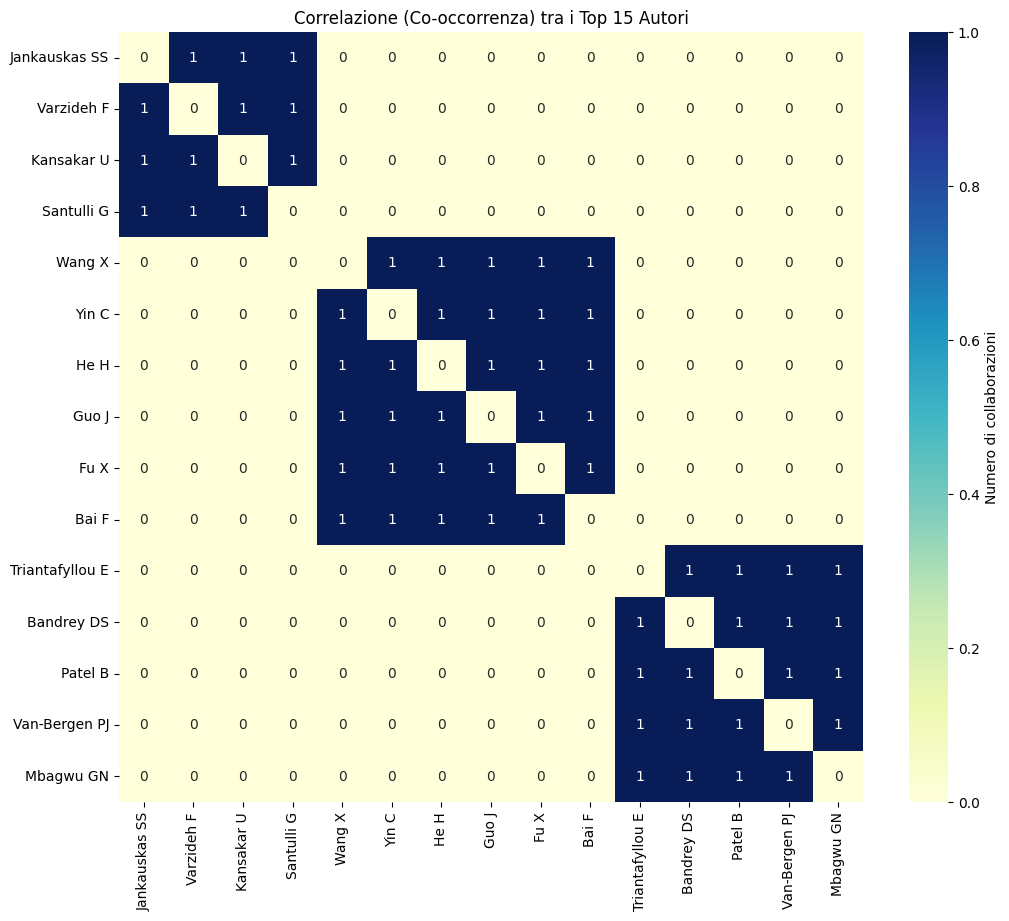


Coppie di autori con più collaborazioni:
Jankauskas SS & Kansakar U: 1
Jankauskas SS & Santulli G: 1
Jankauskas SS & Varzideh F: 1
Kansakar U & Santulli G: 1
Kansakar U & Varzideh F: 1


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

def analyze_author_correlations(df):
    if df.empty:
        print("Il DataFrame è vuoto.")
        return

    # 1. Pulizia e split degli autori
    # Assumiamo che gli autori siano separati da virgole
    author_lists = df['Authors'].str.split(', ').tolist()

    # 2. Conteggio delle co-occorrenze
    co_occurrence = Counter()
    individual_counts = Counter()

    for authors in author_lists:
        # Rimuovi eventuali spazi bianchi extra e nomi vuoti
        authors = [a.strip() for a in authors if a.strip()]
        individual_counts.update(authors)
        # Genera tutte le coppie possibili in un articolo
        for combo in combinations(sorted(authors), 2):
            co_occurrence[combo] += 1

    # 3. Trasformazione in DataFrame per la visualizzazione
    if not co_occurrence:
        print("Non sono state trovate co-occorrenze tra gli autori.")
        return

    # Filtriamo gli autori più frequenti per mantenere il grafico leggibile
    top_authors = [auth for auth, count in individual_counts.most_common(15)]

    # Creazione della matrice
    matrix_df = pd.DataFrame(0, index=top_authors, columns=top_authors)
    for (a1, a2), count in co_occurrence.items():
        if a1 in top_authors and a2 in top_authors:
            matrix_df.at[a1, a2] = count
            matrix_df.at[a2, a1] = count

    # 4. Plotting
    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix_df, annot=True, cmap='YlGnBu', cbar_kws={'label': 'Numero di collaborazioni'})
    plt.title('Correlazione (Co-occorrenza) tra i Top 15 Autori')
    plt.show()

    # Stampiamo anche le coppie più forti
    print("\nCoppie di autori con più collaborazioni:")
    for combo, count in co_occurrence.most_common(5):
        print(f"{combo[0]} & {combo[1]}: {count}")

analyze_author_correlations(results_df)

In [17]:
if not results_df.empty:
    print("Link agli articoli su PubMed:\n")
    for index, row in results_df.iterrows():
        url = f"https://pubmed.ncbi.nlm.nih.gov/{row['PMID']}/"
        print(f"- {row['Title']}")
        print(f"  Link: {url}\n")
else:
    print("Nessun risultato disponibile per generare link.")

Link agli articoli su PubMed:

- Artificial Intelligence in Cardiovascular Medicine: A Giant Step in Personalized Medicine?
  Link: https://pubmed.ncbi.nlm.nih.gov/42042558/

- Benchmarking public large language model responses to patient-facing inflammatory bowel disease questions: informational quality, transparency proxies, and readability.
  Link: https://pubmed.ncbi.nlm.nih.gov/42040103/

- Neck adiposity on standard oncologic CT predicts radiation-induced carotid disease in oropharyngeal cancer.
  Link: https://pubmed.ncbi.nlm.nih.gov/42035215/

- Accelerating Leigh syndrome drug discovery through deep learning screening in brain organoids.
  Link: https://pubmed.ncbi.nlm.nih.gov/42009687/

- Generalization of Left Ventricular Segmentation Models to LVNC Patients: A Comparative Study.
  Link: https://pubmed.ncbi.nlm.nih.gov/41998457/



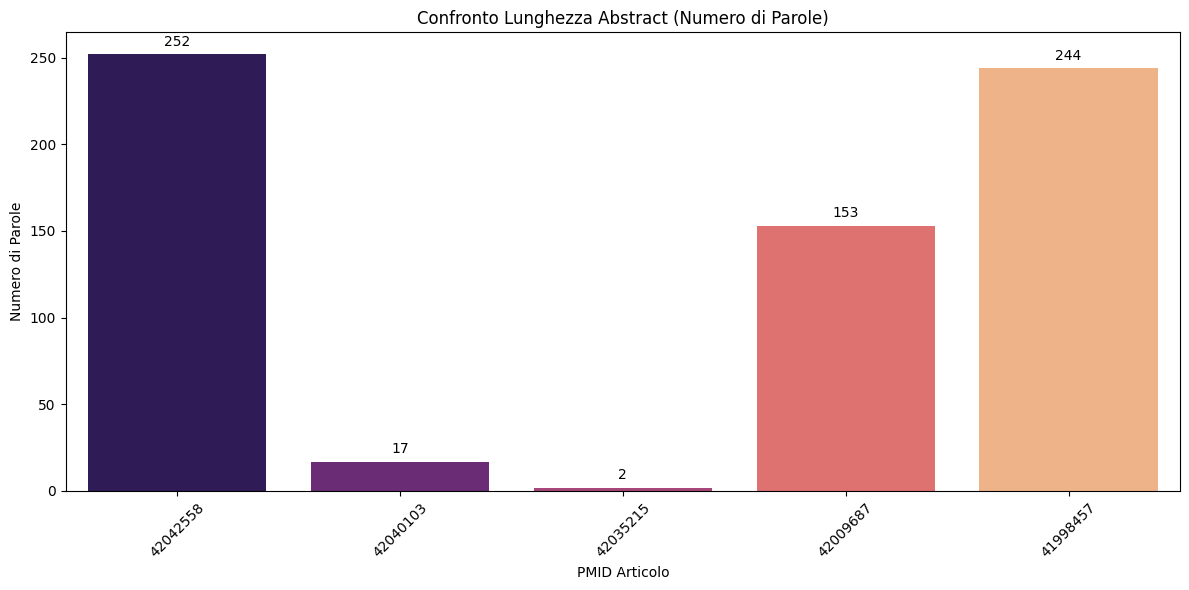

Lunghezza media degli abstract: 133.60 parole.
Abstract più lungo: 252 parole (PMID: 42042558)


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def compare_abstract_lengths(df):
    if df.empty:
        print("Il DataFrame è vuoto.")
        return

    # Calcolo della lunghezza (numero di parole) per ogni abstract
    df['Abstract_Length'] = df['Abstract'].apply(lambda x: len(str(x).split()))

    # Creazione del grafico
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x='PMID', y='Abstract_Length', data=df, palette='magma', hue='PMID', legend=False)

    plt.title('Confronto Lunghezza Abstract (Numero di Parole)')
    plt.xlabel('PMID Articolo')
    plt.ylabel('Numero di Parole')
    plt.xticks(rotation=45)

    # Aggiunta etichette sui valori
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

    plt.tight_layout()
    plt.show()

    # Statistiche rapide
    avg_len = df['Abstract_Length'].mean()
    print(f"Lunghezza media degli abstract: {avg_len:.2f} parole.")
    print(f"Abstract più lungo: {df['Abstract_Length'].max()} parole (PMID: {df.loc[df['Abstract_Length'].idxmax(), 'PMID']})")

compare_abstract_lengths(results_df)

### Bibliografia Selezionata: Deep Learning in Cardiology

| Anno | Rivista | Titolo | Link |
| :--- | :--- | :--- | :--- |
| 2026 | J Pers Med | Artificial Intelligence in Cardiovascular Medicine | [PubMed](https://pubmed.ncbi.nlm.nih.gov/42042558/) |
| 2026 | IBD Journal | Benchmarking LLM responses to IBD questions | [PubMed](https://pubmed.ncbi.nlm.nih.gov/42040103/) |
| 2026 | Oncology CT | Neck adiposity and radiation-induced carotid disease | [PubMed](https://pubmed.ncbi.nlm.nih.gov/42035215/) |
| 2026 | Brain Org. | Deep learning screening for Leigh syndrome | [PubMed](https://pubmed.ncbi.nlm.nih.gov/42009687/) |
| 2026 | J Imaging Inf | LV Segmentation Models for LVNC Patients | [PubMed](https://pubmed.ncbi.nlm.nih.gov/41998457/) |